In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns

In [18]:
df = pd.read_csv('bmw.csv')[['price','mileage','tax']]

In [19]:
df.head()

,price,mileage,tax
0,11200,67068,125
1,27000,14827,145
2,16000,62794,160
3,12750,26676,145
4,14500,39554,160


In [30]:
df.shape

(10781, 3)

In [24]:
df['tax'].describe()

count    10781.000000
mean       131.702068
std         61.510755
min          0.000000
25%        135.000000
50%        145.000000
75%        145.000000
max        580.000000
Name: tax, dtype: float64

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_5532\2122605567.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['tax'])


<Axes: xlabel='tax', ylabel='Density'>

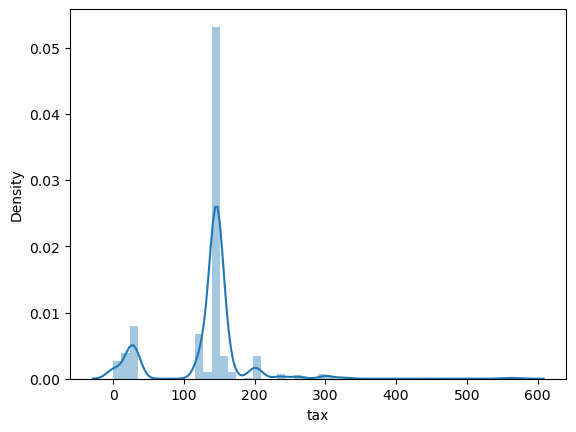

In [21]:
sns.distplot(df['tax'])

<Axes: xlabel='tax'>

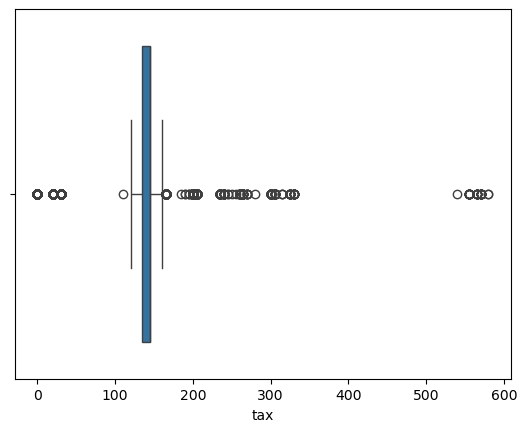

In [28]:
sns.boxplot(x=df['tax'])

In [95]:
upperlimit = df['tax'].quantile(0.90)
lowerlimit = df['tax'].quantile(0.05)

In [96]:
upperlimit, lowerlimit

(160.0, 20.0)

In [97]:
df[(df['tax'] > upperlimit) | (df['tax'] < lowerlimit)]

,price,mileage,tax
23,9400,44498,0
28,19750,96213,165
29,17400,50316,200
32,17100,25269,0
35,13000,61818,0
...,...,...,...
10766,8700,54987,0
10770,6480,70500,325
10772,10200,41435,0
10775,20000,44147,200


In [98]:
# Trimmimg

new_df = df[(df['tax'] < upperlimit) & (df['tax'] > lowerlimit)]

In [99]:
new_df.shape

(8606, 3)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_5532\690830677.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['tax'])


<Axes: xlabel='tax', ylabel='Density'>

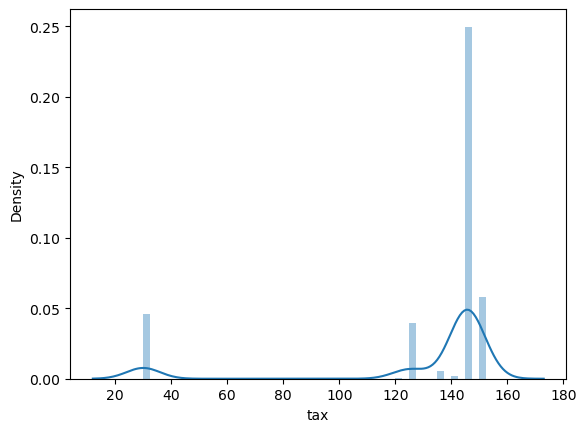

In [100]:
sns.distplot(new_df['tax'])

<Axes: xlabel='tax'>

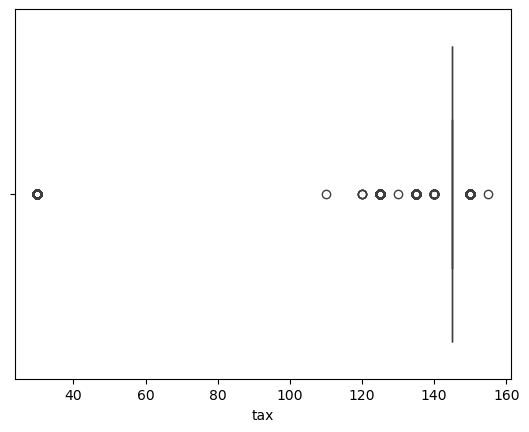

In [101]:
sns.boxplot(x=new_df['tax'])

In [102]:
# Capping --> Winsorization
df2 = df.copy()

df2['tax'] = np.where(df['tax'] >= upperlimit,
        upperlimit,
        np.where(df['tax'] <= lowerlimit,
        lowerlimit,
        df['tax']))

In [103]:
df2.shape

(10781, 3)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_5532\834329367.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2['tax'])


<Axes: xlabel='tax', ylabel='Density'>

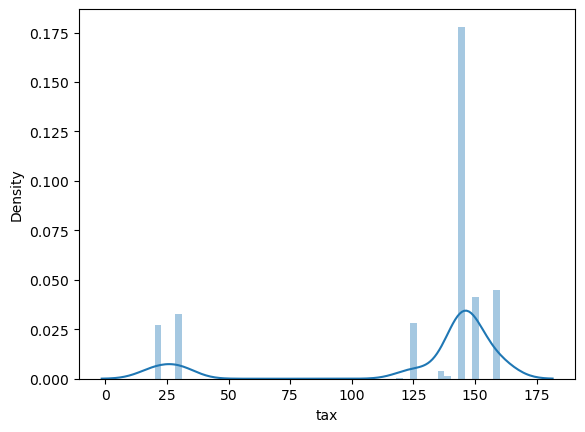

In [104]:
sns.distplot(df2['tax'])

<Axes: xlabel='tax'>

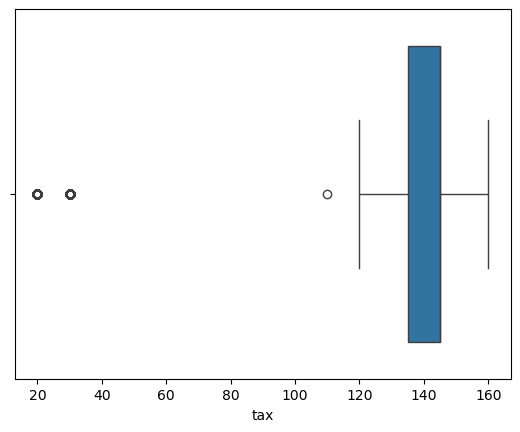

In [105]:
sns.boxplot(x=df2['tax'])